# 05 Audio Features EDA

This notebook explores the audio-feature data in the Spotify dataset.

The analysis focuses on:
- audio feature distributions
- feature relationships and correlations
- track-level musical characteristics
- variability across songs
- how audio features may support the recommendation system

## 1. Load Audio Features Data

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
audio_features = con.execute("""
    SELECT *
    FROM tracks
""").df()

audio_features.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101939, 32)

In [3]:
audio_features.head()

,column00,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,...,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,...,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,...,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,...,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,...,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track


## 2. Basic Dataset Information

In [4]:
audio_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101939 entries, 0 to 101938
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   column00           101939 non-null  int64  
 1   acousticness       101939 non-null  float64
 2   album_id           101939 non-null  object 
 3   analysis_url       101939 non-null  object 
 4   artists_id         101939 non-null  object 
 5   available_markets  101939 non-null  object 
 6   country            101939 non-null  object 
 7   danceability       101939 non-null  float64
 8   disc_number        101939 non-null  float64
 9   duration_ms        101939 non-null  float64
 10  energy             101939 non-null  float64
 11  href               101939 non-null  object 
 12  id                 101939 non-null  object 
 13  instrumentalness   101939 non-null  float64
 14  key                101939 non-null  float64
 15  liveness           101939 non-null  float64
 16  lo

In [5]:
audio_features.describe(include="all")

,column00,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
count,101939.000000,101939.000000,101939,101939,101939,101939,101939,101939.000000,101939.000000,1.019390e+05,...,101939,101939.000000,101939.000000,101939.000000,101939,101939,101939.000000,101939,101939.000000,101939
unique,NaN,NaN,75503,101939,54673,3181,3,NaN,NaN,NaN,...,99728,NaN,NaN,NaN,101939,100,NaN,101939,NaN,1
top,NaN,NaN,65ujg0YuXfO1usl4EPhqVY,https://api.spotify.com/v1/audio-analysis/5qlj...,['0LyfQWJT6nXafLPZqxe9Of'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",AR,NaN,NaN,NaN,...,https://p.scdn.co/mp3-preview/924e366ee6b2ded7...,NaN,NaN,NaN,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_12,NaN,spotify:track:5qljLQuKnNJf4F4vfxQB0V,NaN,track
freq,NaN,NaN,100,1,284,65351,50437,NaN,NaN,NaN,...,6,NaN,NaN,NaN,1,2241,NaN,1,NaN,101939
mean,50969.000000,0.352124,NaN,NaN,NaN,NaN,NaN,0.586015,1.032166,2.467708e+05,...,NaN,0.128841,118.358527,3.875651,NaN,NaN,4.608060,NaN,0.482813,NaN
std,29427.398883,0.334855,NaN,NaN,NaN,NaN,NaN,0.177724,0.566789,1.904303e+05,...,NaN,0.203324,30.224074,0.517008,NaN,NaN,7.181805,NaN,0.261690,NaN
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.155000e+03,...,NaN,0.000000,0.000000,0.000000,NaN,NaN,1.000000,NaN,0.000000,NaN
25%,25484.500000,0.040700,NaN,NaN,NaN,NaN,NaN,0.480000,1.000000,1.840000e+05,...,NaN,0.036400,95.973000,4.000000,NaN,NaN,1.000000,NaN,0.271000,NaN
50%,50969.000000,0.238000,NaN,NaN,NaN,NaN,NaN,0.610000,1.000000,2.168930e+05,...,NaN,0.050600,118.067000,4.000000,NaN,NaN,2.000000,NaN,0.477000,NaN
75%,76453.500000,0.645000,NaN,NaN,NaN,NaN,NaN,0.714000,1.000000,2.610550e+05,...,NaN,0.104000,136.045000,4.000000,NaN,NaN,6.000000,NaN,0.693000,NaN


In [6]:
audio_features.isnull().sum().sort_values(ascending=False)

column00             0
acousticness         0
valence              0
uri                  0
track_number         0
track_name_prev      0
track_href           0
time_signature       0
tempo                0
speechiness          0
preview_url          0
popularity           0
playlist             0
name                 0
mode                 0
lyrics               0
loudness             0
liveness             0
key                  0
instrumentalness     0
id                   0
href                 0
energy               0
duration_ms          0
disc_number          0
danceability         0
country              0
available_markets    0
artists_id           0
analysis_url         0
album_id             0
type                 0
dtype: int64

In [7]:
audio_features.duplicated().sum()

0

## 3. Numerical Feature Detection

In [8]:
numeric_cols = audio_features.select_dtypes(
    include=["int64", "float64"]
).columns

numeric_cols.tolist()

['column00',
 'acousticness',
 'danceability',
 'disc_number',
 'duration_ms',
 'energy',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'mode',
 'popularity',
 'speechiness',
 'tempo',
 'time_signature',
 'track_number',
 'valence']

In [9]:
print("Total numerical columns:", len(numeric_cols))

Total numerical columns: 17


In [10]:
audio_features[numeric_cols].describe()

,column00,acousticness,danceability,disc_number,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,time_signature,track_number,valence
count,101939.000000,101939.000000,101939.000000,101939.000000,1.019390e+05,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000
mean,50969.000000,0.352124,0.586015,1.032166,2.467708e+05,0.586479,0.148776,5.270858,0.197640,-9.462720,0.618154,39.782311,0.128841,118.358527,3.875651,4.608060,0.482813
std,29427.398883,0.334855,0.177724,0.566789,1.904303e+05,0.260170,0.304024,3.577679,0.175391,6.198508,0.485841,16.790769,0.203324,30.224074,0.517008,7.181805,0.261690
min,0.000000,0.000000,0.000000,1.000000,1.155000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,25484.500000,0.040700,0.480000,1.000000,1.840000e+05,0.411000,0.000000,2.000000,0.095600,-11.149000,0.000000,29.000000,0.036400,95.973000,4.000000,1.000000,0.271000
50%,50969.000000,0.238000,0.610000,1.000000,2.168930e+05,0.629000,0.000037,5.000000,0.124000,-7.599000,1.000000,41.000000,0.050600,118.067000,4.000000,2.000000,0.477000
75%,76453.500000,0.645000,0.714000,1.000000,2.610550e+05,0.798000,0.034400,8.000000,0.241000,-5.509000,1.000000,52.000000,0.104000,136.045000,4.000000,6.000000,0.693000
max,101938.000000,0.996000,0.989000,81.000000,5.505831e+06,1.000000,1.000000,11.000000,0.999000,2.719000,1.000000,97.000000,0.969000,244.035000,5.000000,655.000000,0.993000


## 4. Audio Feature Selection

In [11]:
audio_feature_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "duration_ms",
    "popularity"
]

audio_features_selected = audio_features[audio_feature_cols]

audio_features_selected.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
0,0.294,0.698,0.606,0.000003,0.151,-7.447,0.0262,115.018,0.6220,235584.0,28.0
1,0.863,0.719,0.308,0.000000,0.253,-10.340,0.9220,115.075,0.5890,656960.0,31.0
2,0.750,0.466,0.931,0.000000,0.938,-13.605,0.9440,79.565,0.0850,492840.0,31.0
3,0.763,0.719,0.126,0.000000,0.113,-20.254,0.9380,112.822,0.5330,316578.0,14.0
4,0.770,0.460,0.942,0.000000,0.917,-13.749,0.9430,81.260,0.0906,558880.0,32.0


The selected columns represent the main numerical audio characteristics of tracks. 
Metadata-related columns such as track numbers, disc numbers, URIs, and API links are excluded from the main feature analysis because they do not describe musical properties directly.

## 5. Feature Distributions

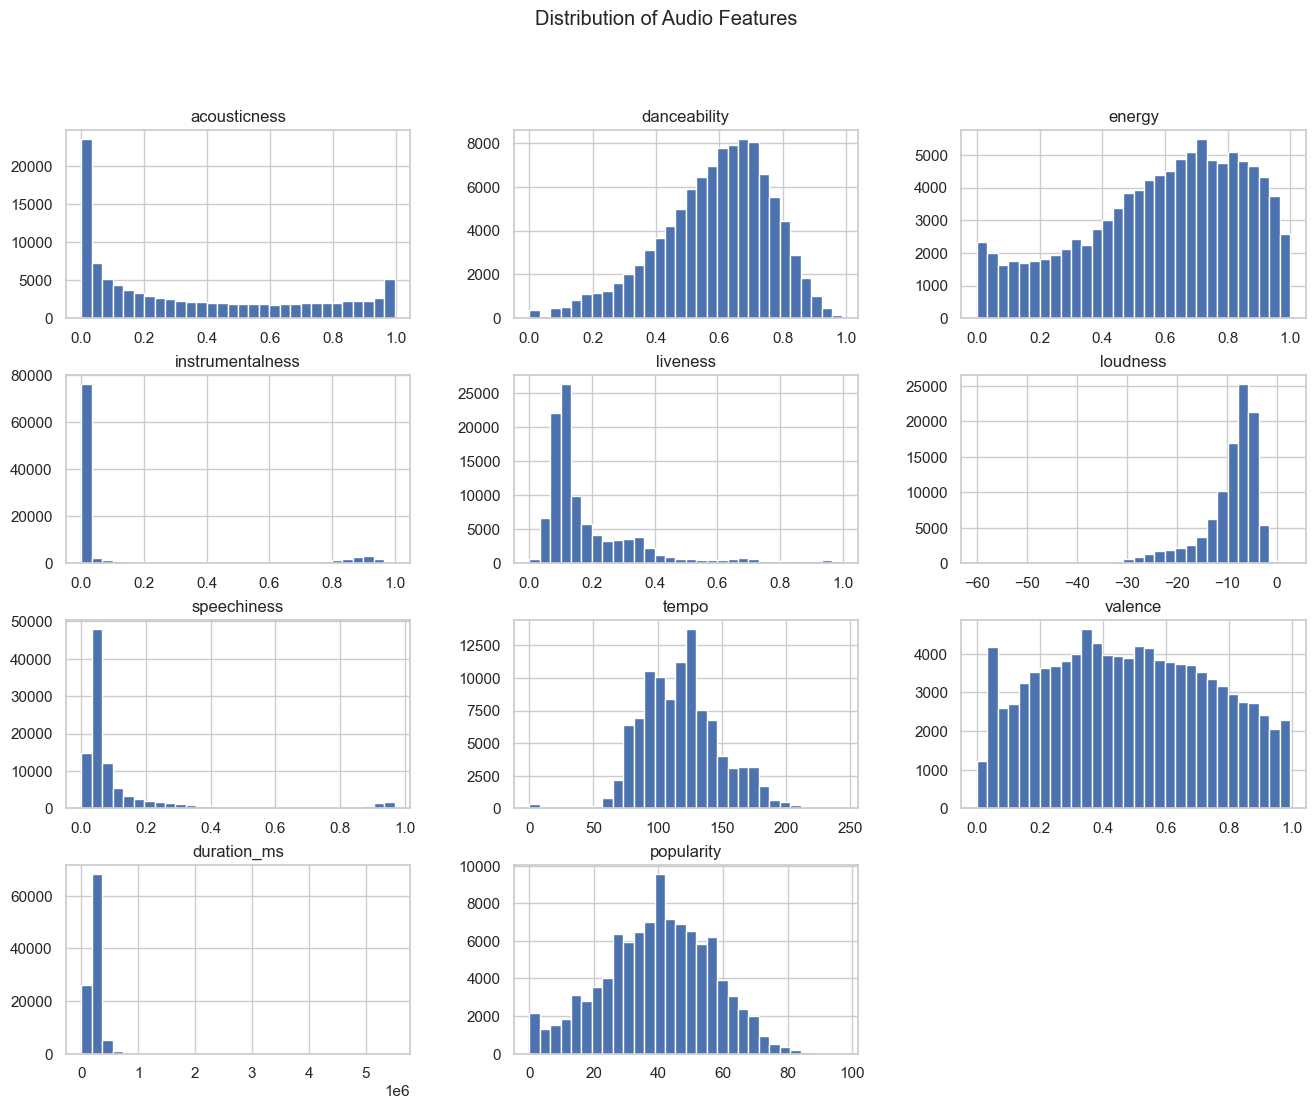

In [28]:
audio_features_selected.hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Audio Features")

plt.show()

## 6. Correlation Matrix

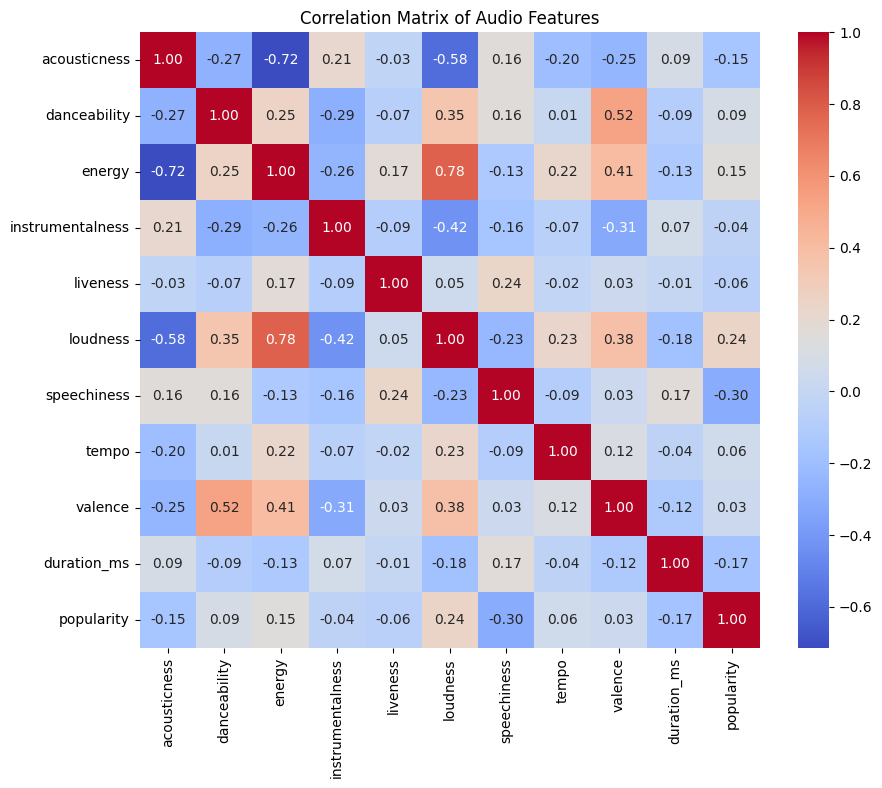

In [13]:
plt.figure(figsize=(10, 8))

corr_matrix = audio_features_selected.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Audio Features")

plt.show()

Strong positive relationships appear between:
- energy and loudness
- danceability and valence

Negative relationships can be observed between:
- acousticness and energy

These relationships may help identify similar tracks for recommendation purposes.

## 7. Outlier Investigation

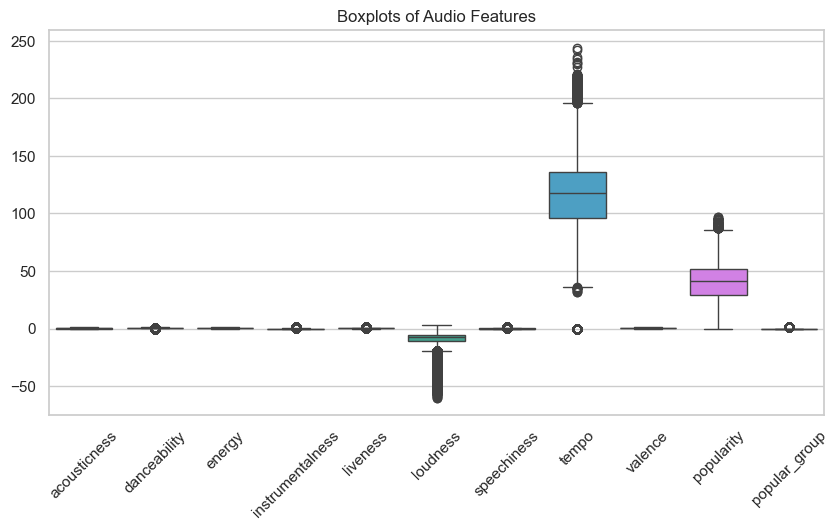

In [26]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=audio_features_selected.drop(columns=["duration_ms"])
)

plt.xticks(rotation=45)

plt.title("Boxplots of Audio Features")

plt.show()

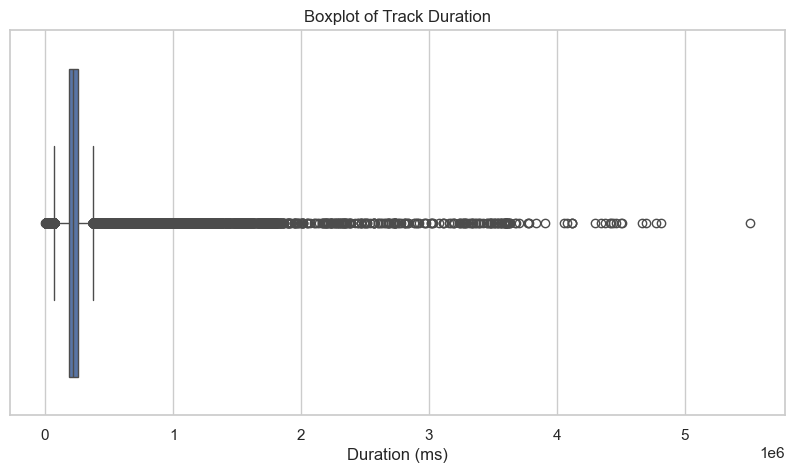

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=audio_features_selected["duration_ms"]
)

plt.title("Boxplot of Track Duration")

plt.xlabel("Duration (ms)")

plt.show()

The distributions show that several audio features are highly skewed, particularly instrumentalness, speechiness, and acousticness. 

Most tracks contain vocals, have relatively low speech content, and are not purely acoustic. Energy and danceability tend to concentrate around medium-to-high values, reflecting common characteristics of modern popular music.

The dataset also contains several extreme outliers in track duration, suggesting that some entries may represent podcasts, live recordings, or unusually long audio content.

## 8. Popular vs Non-Popular Songs

In [17]:
audio_features_selected["popular_group"] = (
    audio_features_selected["popularity"] >= 60
)

audio_features_selected.groupby(
    "popular_group"
).mean()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
popular_group,,,,,,,,,,,
False,0.359015,0.581775,0.582429,0.156141,0.199618,-9.674884,0.134173,118.134420,0.481272,250437.676348,36.142278
True,0.301492,0.617165,0.616232,0.094670,0.183113,-7.903998,0.089670,120.004987,0.494133,219831.161058,66.524769


## 9 Danceability Comparison

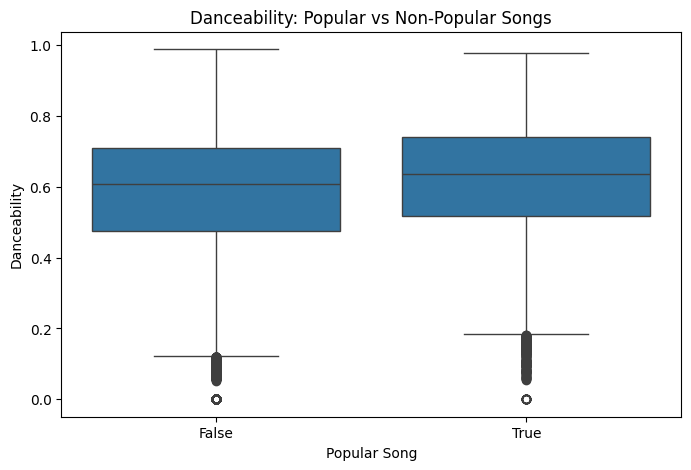

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected,
    x="popular_group",
    y="danceability"
)

plt.title("Danceability: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Danceability")

plt.show()

## 10 Energy Comparison

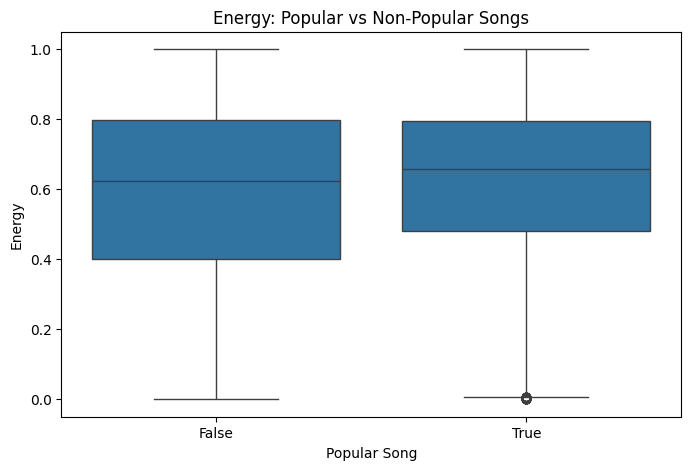

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected,
    x="popular_group",
    y="energy"
)

plt.title("Energy: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Energy")

plt.show()

## 11 Acousticness Comparison

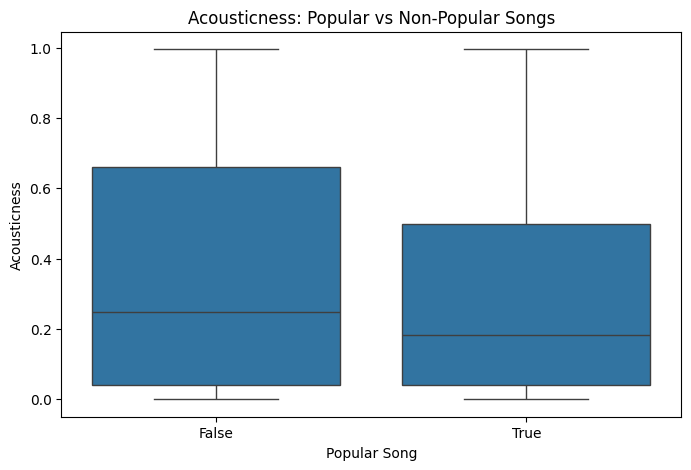

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected,
    x="popular_group",
    y="acousticness"
)

plt.title("Acousticness: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Acousticness")

plt.show()

## 12 Loudness Comparison

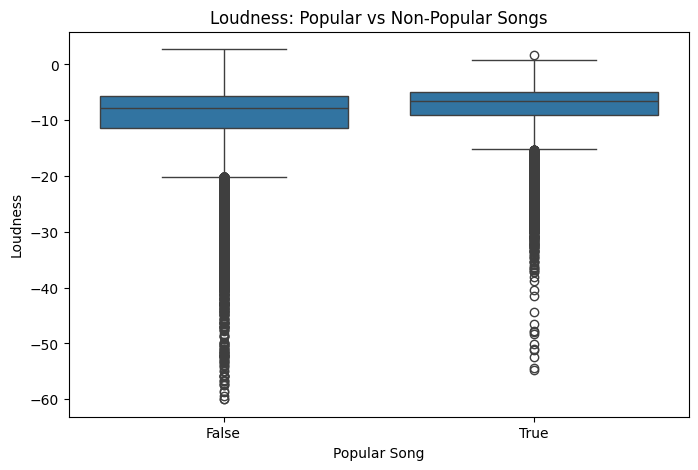

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected,
    x="popular_group",
    y="loudness"
)

plt.title("Loudness: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Loudness")

plt.show()

## 13 Instrumentalness Comparison

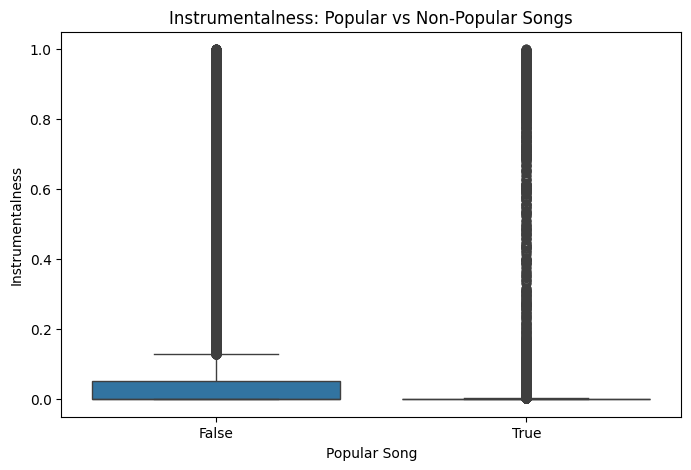

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected,
    x="popular_group",
    y="instrumentalness"
)

plt.title("Instrumentalness: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Instrumentalness")

plt.show()

## 14 Speechiness Comparison

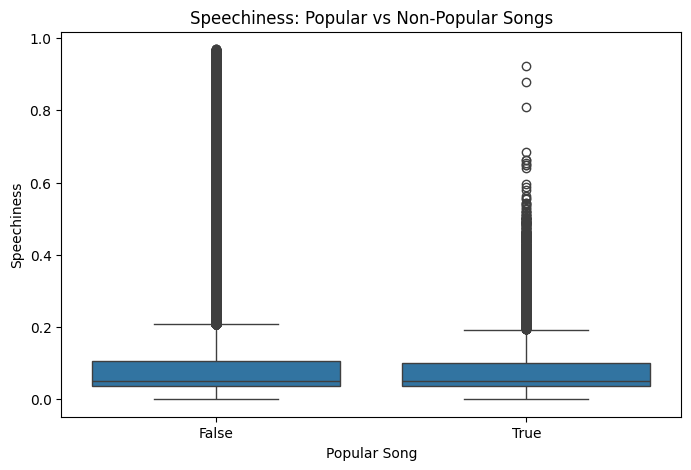

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected,
    x="popular_group",
    y="speechiness"
)

plt.title("Speechiness: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Speechiness")

plt.show()

## 15 Duration Comparison

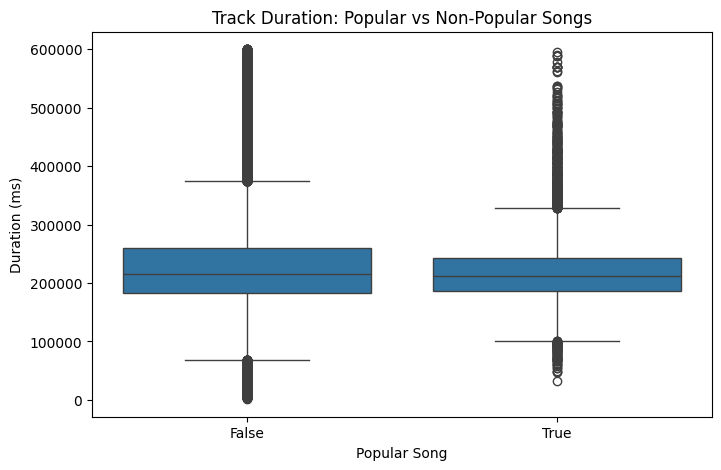

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=audio_features_selected[
        audio_features_selected["duration_ms"] < 600000
    ],
    x="popular_group",
    y="duration_ms"
)

plt.title("Track Duration: Popular vs Non-Popular Songs")
plt.xlabel("Popular Song")
plt.ylabel("Duration (ms)")

plt.show()

## 16 Interpretation

Popular songs tend to have slightly higher danceability, energy, and loudness values compared to less popular songs. They also show lower acousticness and instrumentalness on average, suggesting that mainstream tracks are generally more energetic, vocal-focused, and electronically produced.

Speechiness is also lower for more popular songs, indicating that highly speech-heavy tracks are less common among mainstream music. In addition, popular tracks appear to be slightly shorter on average.

These differences suggest that certain audio characteristics may contribute to listener preference and commercial success, making them potentially useful signals for recommendation models.

In [29]:
con.close()